# Spotify Genre Classification

This project will guide you through the process of building a music genre classifier. You’ll start by selecting specific genres to work with, then examine correlations among different musical features. Using these correlations, you'll identify any redundant features that could be removed to improve model performance and simplify the dataset.

After preparing your data, you’ll train and evaluate three different classification models: Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Random Forest. By the end of this project, you’ll compare these models to see which performs best in classifying music genres.

Let’s get started and see how well machine learning can predict the genre of a song based on its characteristics!

In [452]:
##from google.colab import drive
##drive.mount('/content/drive')

## The dataset was imported into the Colab session storage

## Import Libraries

In [453]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load and Explore Dataset
It’s essential to load and explore your dataset to understand its structure, identify any missing or inconsistent values, and get a sense of the types of features available. This initial exploration helps you make informed decisions about data cleaning, feature selection, and preprocessing steps.

In [454]:
# Load the dataset
df = pd.read_csv('/dataset.csv')

# Display initial dataset information
print("First 5 rows of the dataset:")
print(df.head(5))
print("\nInitial Data Overview:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

First 5 rows of the dataset:
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          

## Select Genres

For this project, you’ll conduct three classification experiments. One experiment should be binary (classifying between two genres), while the other two will be multiclass (classifying among multiple genres).

Choose Your Genres
Below are some genre options available in the dataset:

`['rock', 'rap', 'jazz', 'latin', 'country', 'pop', 'classical', 'electronic', 'acoustic', 'r-and-b']`

Feel free to explore the dataset if you'd like to use other genres, this dataset has over 100 genres available!

#Instructions
**Binary Experiment:** Choose two genres that you want to classify between (e.g., Rock vs. Jazz). This experiment will help you understand classification when only two classes are present.

**Multiclass Experiments:** For the other two experiments, choose three or more genres to create multiclass classification problems (e.g., Rock, Pop, and Classical). These experiments will show how classification models perform with more categories.



In [455]:
# Example: selected_genres = ['rock', 'rap', 'jazz', 'latin', 'country', 'pop']
selected_genres = ['pop', 'country', 'jazz']  # <- Enter your genres here

##print(df['track_genre'].unique())

# Filter for the selected genres
df = df[df['track_genre'].isin(selected_genres)]

df = df.groupby('track_genre').apply(lambda x: x.sample(300, random_state=42)).reset_index(drop=True)

/tmp/ipykernel_6186/2045889097.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('track_genre').apply(lambda x: x.sample(300, random_state=42)).reset_index(drop=True)


## Data Cleaning and Preparation

Preparing data for machine learning involves selecting relevant columns, handling missing values, and encoding categorical variables. First, selecting only the most relevant columns focuses the dataset on essential features, simplifying the model and often improving performance. Next, handling missing values is crucial because incomplete data can disrupt model training; we address this by either removing rows with missing entries or filling them in with appropriate values, such as the mean or median. Finally, encoding categorical variables (like genre) into numerical format allows machine learning algorithms to process non-numeric data. By assigning a unique number to each category using label encoding, we enable the model to interpret these variables accurately, making our dataset ready for analysis.


In [456]:
# Select relevant columns
df = df[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
         'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'explicit', 'track_genre']]

# Drop any rows with missing values
df.dropna(inplace=True)

# Convert 'track_genre' to numerical values (Label Encoding)
label_encoder = LabelEncoder()
df['track_genre'] = label_encoder.fit_transform(df['track_genre'])

# Convert 'explicit' to binary 1/0
df['explicit'] = df['explicit'].astype(int)

# Show class distribution for genres after filtering and sampling
print("\nSampled Genre Distribution:")
print(df['track_genre'].value_counts())


Sampled Genre Distribution:
track_genre
0    300
1    300
2    300
Name: count, dtype: int64


## Correlation Analysis

The heatmap above shows correlations between features in the dataset. High correlation values (close to 1 or -1) indicate features that likely carry similar information. Removing one of these correlated features can reduce the dataset’s dimensionality, making the model simpler and potentially improving performance.



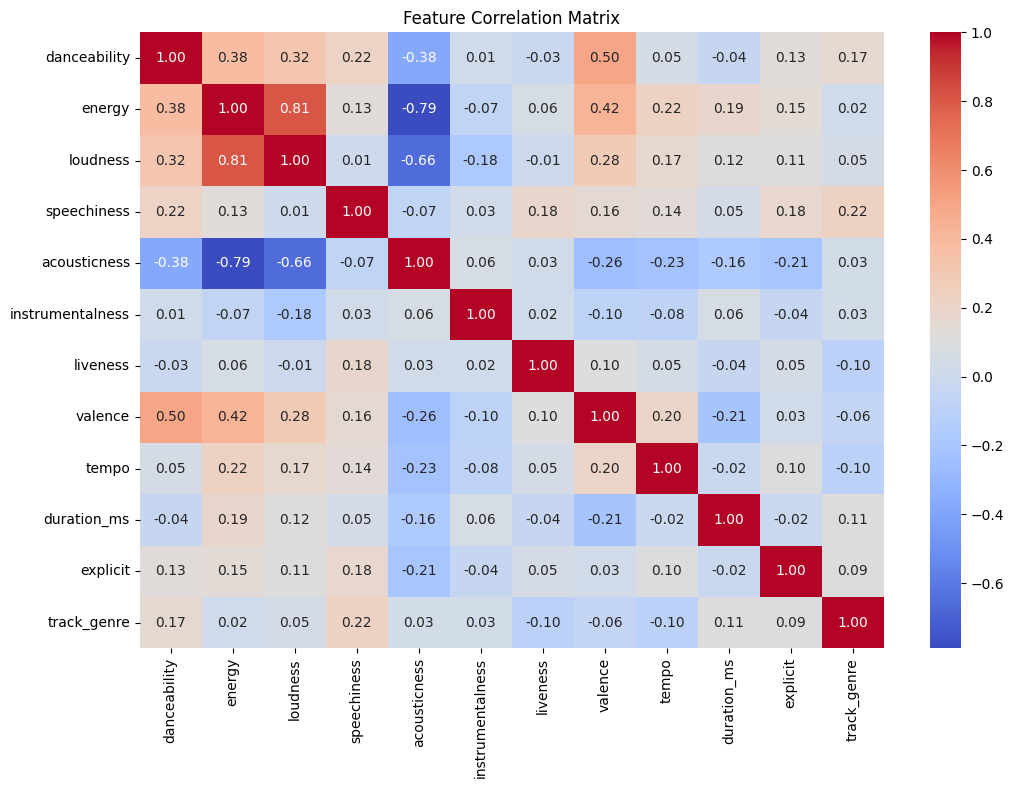

In [457]:

# Heatmap Correlation Matrix
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()



## Feature Selection Experiments
**Experiment 1: Train with all features**
Train your models (SVM, KNN, and Random Forest) using all features to establish a baseline. You can do this by running the rest of the notebook without making any changes.

**Experiment 2: Remove one highly correlated feature**
Identify a pair of features with a correlation around |0.7| or higher, then remove one and re-train your models. Note any differences compared to the baseline.

**Experiment 3: Remove multiple correlated features**
Remove multiple features with correlations around |0.7| or higher. Re-train your models and compare these results with both the baseline and Experiment 2.

These experiments will help you understand the impact of correlated features on model performance.

In [458]:
# Example: remove_features = ['danceability', 'liveness', 'speechiness', 'instrumentalness', 'duration_ms']
remove_features = ['energy']  # <- Enter  features to remove here

# Drop the selected features
df.drop(columns=remove_features, inplace=True)

## Prepare Data for Modeling

Split the data into training and testing sets and standardize the features.

In [459]:
# Feature and target selection
X = df.drop(columns=['track_genre'])
y = df['track_genre']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Evaluation

Train and evaluate three models: Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Random Forest. Compare their accuracies to find the best-performing model.

In [460]:
# 1. Support Vector Machine (SVM)
print("\nSupport Vector Machine (SVM) Results:")
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n")
print(selected_genres)
print(cm)


Support Vector Machine (SVM) Results:
SVM Accuracy: 0.7222222222222222
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.71      0.68        83
           1       0.86      0.74      0.80       111
           2       0.64      0.71      0.67        76

    accuracy                           0.72       270
   macro avg       0.72      0.72      0.72       270
weighted avg       0.74      0.72      0.73       270

Confusion Matrix:

['pop', 'country', 'jazz']
[[59  7 17]
 [15 82 14]
 [16  6 54]]


In [461]:
# 1. Support Vector Machine (SVM) with OVR
print("\nSupport Vector Machine (SVM) with OVR Results:")
svm = SVC()

ovr_svm = OneVsRestClassifier(svm)
ovr_svm.fit(X_train, y_train)
y_pred_svm = ovr_svm.predict(X_test)

print("SVM Accuracy with OVR:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n")
print(selected_genres)
print(cm)


Support Vector Machine (SVM) with OVR Results:
SVM Accuracy with OVR: 0.7444444444444445
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.70      0.69        83
           1       0.88      0.77      0.82       111
           2       0.66      0.76      0.71        76

    accuracy                           0.74       270
   macro avg       0.74      0.74      0.74       270
weighted avg       0.76      0.74      0.75       270

Confusion Matrix:

['pop', 'country', 'jazz']
[[58  7 18]
 [14 85 12]
 [13  5 58]]


In [462]:
# 2. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n")
print(selected_genres)
print(cm)


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.6851851851851852
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.69      0.62        83
           1       0.85      0.74      0.79       111
           2       0.64      0.61      0.62        76

    accuracy                           0.69       270
   macro avg       0.68      0.68      0.68       270
weighted avg       0.70      0.69      0.69       270

Confusion Matrix:

['pop', 'country', 'jazz']
[[57  7 19]
 [22 82  7]
 [22  8 46]]


In [463]:
# 2. K-Nearest Neighbors (KNN) wrapped with OvR

print("\nK-Nearest Neighbors (KNN) with OvR Results:")
knn = KNeighborsClassifier(n_neighbors=5)

## One-vs-Rest (OvR) model
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, y_train)
y_pred_knn = ovr_knn.predict(X_test)

print("KNN OVR Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n")
print(selected_genres)
print(cm)


K-Nearest Neighbors (KNN) with OvR Results:
KNN OVR Accuracy: 0.7
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.65      0.63        83
           1       0.86      0.75      0.80       111
           2       0.61      0.68      0.65        76

    accuracy                           0.70       270
   macro avg       0.69      0.69      0.69       270
weighted avg       0.71      0.70      0.70       270

Confusion Matrix:

['pop', 'country', 'jazz']
[[54  7 22]
 [17 83 11]
 [18  6 52]]



Random Forest Results:
Random Forest Accuracy: 0.7962962962962963
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.77      0.75        83
           1       0.91      0.80      0.85       111
           2       0.73      0.82      0.77        76

    accuracy                           0.80       270
   macro avg       0.79      0.80      0.79       270
weighted avg       0.80      0.80      0.80       270

Confusion Matrix:

['pop', 'country', 'jazz']
[[64  6 13]
 [12 89 10]
 [11  3 62]]


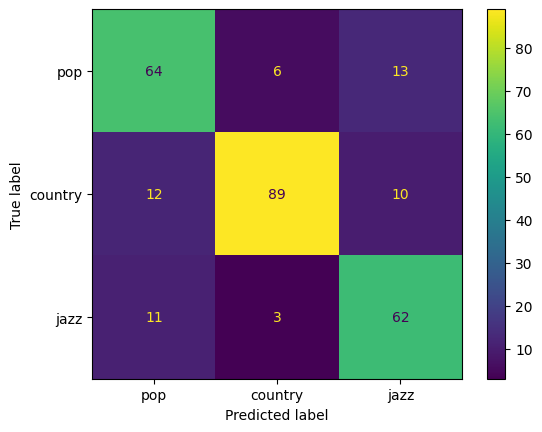

In [464]:
# 3. Random Forest
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n")
print(selected_genres)
print(cm)


# 2. Pass the matrix and custom labels to the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_genres)

# 3. Render the plot
disp.plot()
plt.show()


Random Forest OvR Results:
Random Forest with OvR Accuracy: 0.7888888888888889
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75        83
           1       0.93      0.79      0.85       111
           2       0.69      0.82      0.75        76

    accuracy                           0.79       270
   macro avg       0.79      0.79      0.78       270
weighted avg       0.80      0.79      0.79       270

Confusion Matrix:

['pop', 'country', 'jazz']
[[63  4 16]
 [11 88 12]
 [11  3 62]]


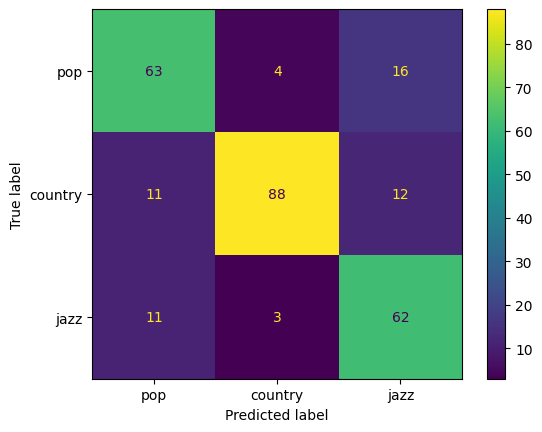

In [465]:
# 3. Random Forest with OvR
print("\nRandom Forest OvR Results:")
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_ovr = OneVsRestClassifier(rf)
rf_ovr.fit(X_train, y_train)
y_pred_rf = rf_ovr.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest with OvR Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n")
print(selected_genres)
print(cm)


# 2. Pass the matrix and custom labels to the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_genres)

# 3. Render the plot
disp.plot()
plt.show()

## Model Comparison

Compare model accuracies to determine the best model for genre classification.

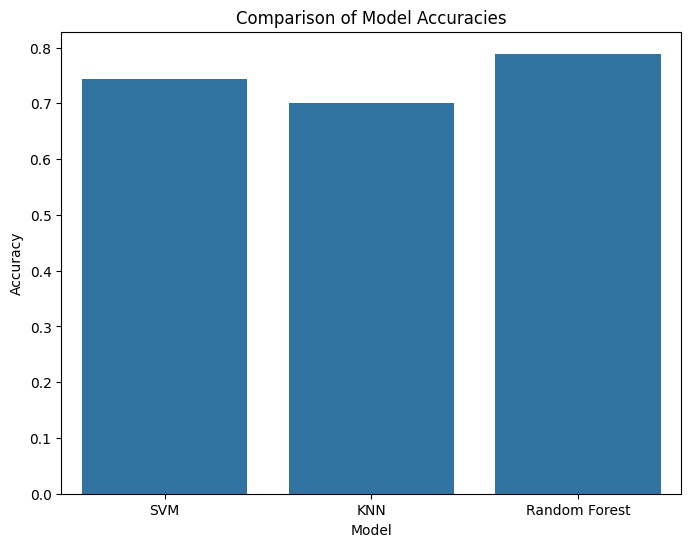

In [466]:
# Comparison of Model Accuracies
model_names = ['SVM', 'KNN', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

# Analysis (also attached as a separate markdown document)

## Binary classification

In this section, I analyzed the performance of SVM, KNN and Random Forest classifiers in binary classification tests:
```
selected_genres = ['world-music', 'pop']
```

I noticed that the provided dataset does not have a feature related to language (i.e. the language in which a track is performed), and I was curious to see how `world_music` is classified in the absence of this feature.

The first set of tests was executed with 100 tracks (rows) per genre sample.

### Correlation analysis
The first set of tests resulted in a correlation score `danceability` and `energy` of 0.70, with the other correlation scores below 0.70.


### Accuracy analysis

With the `danceability` feature removed, the KNN classification model outperformed SVM and Random forest by a small margin, as confirmed by the accuracy scores as well as the ROC-AUC scores:

```
Support Vector Machine (SVM) Results:
SVM Accuracy: 0.8166666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83        31
           1       0.82      0.79      0.81        29

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60

Confusion Matrix:
 [[26  5]
 [ 6 23]]
```

```
K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.8333333333333334
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84        31
           1       0.83      0.83      0.83        29

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Confusion Matrix:
 [[26  5]
 [ 5 24]]
```

```
Random Forest Results:
Random Forest Accuracy: 0.8166666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83        31
           1       0.82      0.79      0.81        29

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60

Confusion Matrix:
 [[26  5]
 [ 6 23]]
```

```
ROC-AUC Score SVM: 0.8159
ROC-AUC Score KNN: 0.8331
ROC-AUC Score Random Forest: 0.8159
```

### Records per sample = 500
As these scores turned out to be extemely close for all three models, I increased the number of records per sample to provide each model with more training data.

Setting the number of records per sample at 500 revealed more correlated features:
`loudness` and `instrumentalness`: correlation score 0.72
`energy` and `acousticness`: correlation score 0.70
`danceability` and `valence`:correlation score 0.68

Removing `loudness` and `energy` resulted in the Random Forest model slightly outperforming SVN and KNN, with higher accuracy and ROC-AUC scores for all models:

```
Support Vector Machine (SVM) Results:
SVM Accuracy: 0.8566666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       150
           1       0.88      0.82      0.85       150

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

Confusion Matrix:
 [[134  16]
 [ 27 123]]

```

```
K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.86
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       150
           1       0.86      0.86      0.86       150

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

Confusion Matrix:
 [[129  21]
 [ 21 129]]
```

```
Random Forest Results:
Random Forest Accuracy: 0.8666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       150
           1       0.89      0.84      0.86       150

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

Confusion Matrix:
 [[134  16]
 [ 24 126]]
```


```
ROC-AUC Score SVM: 0.8567
ROC-AUC Score KNN: 0.8600
ROC-AUC Score Random Forest: 0.8667
```

Increasing the amount of training data increased the accuracy scores for all models, with the Random Forest model showing the highest accuracy score of 0.8667

### Hyperparameter tuning

#### KNN n_neighbors = 9

Increasing the number of neighbors (the `n_neighbors` parameter) from 5 to 9 for the KNN model resulted in lower accuracy scores, with the same feature set and sample size as above (500 records per sample, `loudness` and `energy` features removed):

```
ROC-AUC Score SVM: 0.8567
ROC-AUC Score KNN: 0.8367 (a decrease from 0.8600)
ROC-AUC Score Random Forest: 0.8667
```

This result indicates that the KNN model may be overfitting with `n_neighbors`= 9


#### Random forest n_estimators = 300

Increasing the number of estimators (i.e. the number of trees in the forest that "vote" on the final result) in the Random Forest classifier resulted in a higher score for the Random Forest model:

```
ROC-AUC Score SVM: 0.8567
ROC-AUC Score KNN: 0.8600
ROC-AUC Score Random Forest: 0.8800 (an increase from 0.8667)
```


## Multiclass classification

In this section, I analyzed the performance of SVM, KNN and Random Forest classifiers in multiclass classification tests:
```
selected_genres = ['world-music', 'pop', 'country', 'jazz']
```
The sample size was set to **100** for the initial set of tests.

### Correlation analysis
The initial run showed an `energy` to `acousticness` correlation of 0.76, with the other correlation scores below the threshold of 0.70

### Accuracy analysis
With the `energy` feature removed from the dataset, the Random Forest model outperformed the others with the number of predictors set to 100:

```
Support Vector Machine (SVM) Results:
SVM Accuracy: 0.625
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.54      0.62        37
           1       0.54      0.80      0.65        25
           2       0.58      0.50      0.54        30
           3       0.69      0.71      0.70        28

    accuracy                           0.62       120
   macro avg       0.63      0.64      0.62       120
weighted avg       0.64      0.62      0.62       120

Confusion Matrix:

['world-music', 'pop', 'country', 'jazz']
[[20  8  5  4]
 [ 2 20  3  0]
 [ 6  4 15  5]
 [ 0  5  3 20]]

```

```
K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.65
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.57      0.60        37
           1       0.56      0.80      0.66        25
           2       0.72      0.60      0.65        30
           3       0.73      0.68      0.70        28

    accuracy                           0.65       120
   macro avg       0.66      0.66      0.65       120
weighted avg       0.66      0.65      0.65       120

Confusion Matrix:

['world-music', 'pop', 'country', 'jazz']
[[21  8  4  4]
 [ 3 20  1  1]
 [ 6  4 18  2]
 [ 3  4  2 19]]
```

```
Random Forest Results:
Random Forest Accuracy: 0.6916666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.62      0.67        37
           1       0.64      0.84      0.72        25
           2       0.64      0.60      0.62        30
           3       0.78      0.75      0.76        28

    accuracy                           0.69       120
   macro avg       0.69      0.70      0.69       120
weighted avg       0.70      0.69      0.69       120

Confusion Matrix:

['world-music', 'pop', 'country', 'jazz']
[[23  6  6  2]
 [ 2 21  2  0]
 [ 5  3 18  4]
 [ 2  3  2 21]]
```

Increasing the sample size to 300 resulted in increased accuracy score for the SVM model, with RF still outperforming both SVM and KNN, as shown below. No new correlated features were revealed at this sample size.

```
SVM Accuracy: 0.6805555555555556 (an increase from 0.625)
KNN Accuracy: 0.6277777777777778 (a decrease from 0.65)
Random Forest Accuracy: 0.725 (an increase from 0.692)
```

Increasing the `n_neighbors` hyperparameter for the KNN classifier from 5 to 7 to 9 resulted in incremental increases in KNN accuracy (0.62 to 0.63 to 0.64).
Increasing the `n_estimators` hyperparameter for the Random Forest classifier from 100 to 300 resulted in an accuracy increase frm 0.725 to 0.736.

The accuracy scores are lower overall for multiclass analysis as compared to the binary class analysis. This is likely due to an increase in dimensionality in the dataset.


### Multiclass OvR analysis

In this section, I analyzed the performance of SVM, KNN and Random Forest models wrapped in the OvR (one-versus-rest) classifier in multiclass classification tests. The sample size was set to 300. The following genres were selected (one less than in the multiclass analysis above to reduce dimensionality):

```
selected_genres = ['world-music', 'pop', 'country', 'jazz']
```

#### Accuracy scores

Wrapping the models in an OvR classifier resulted in the following accuracy scores:

```
SVM Accuracy: 0.7222222222222222
SVM Accuracy with OVR: 0.7444444444444445
KNN Accuracy: 0.6851851851851852
KNN Accuracy with OVR: 0.7
Random Forest Accuracy: 0.7962962962962963
Random Forest with OvR Accuracy: 0.7888888888888889
```

Using the OvR classifier resulted in increased accuracy for SVM and KNN models, likely due to the dimensionality decrease resulting from the use of the one-vs-rest classification. The dimensionality decrease has less influence on the Random Forest model, so it makes sense that wrapping it in OvR did not improve the prediction accuracy.


